In [13]:
import pandas as pd

df = pd.read_csv('q3_retail_promotions.csv')  # <-- FIXED
print(df.head())


  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  
3           1            0                    7         259  
4           0            0                    3         277  


In [15]:
import pandas as pd

# Load dataset (make sure CSV is in same folder)
df = pd.read_csv('q3_retail_promotions.csv')

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end feature
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Display sample
print(df.head())

  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

In [16]:
# Sort dataset by date
df = df.sort_values('transaction_date')

# Create 80-20 split (no random split)
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Check sizes
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Optional: verify date range
print("Train date range:", train_df['transaction_date'].min(), "to", train_df['transaction_date'].max())
print("Test date range:", test_df['transaction_date'].min(), "to", test_df['transaction_date'].max())

Train shape: (960, 13)
Test shape: (240, 13)
Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


Markdown Answer

A random split is inappropriate for time-ordered data because it mixes past and future observations, leading to data leakage. In real-world scenarios, we only have access to past data when making predictions. A temporal split ensures that the model is trained on past data and tested on future data, making evaluation realistic and reliable.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Target column
target = 'items_sold'

# Split features and target
X_train = train_df.drop(columns=[target, 'transaction_date'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'transaction_date'])
y_test = test_df[target]

# Define categorical and numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

# Full pipeline (example with Linear Regression placeholder)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Fit ONLY on training data
pipeline.fit(X_train)

# Transform both train and test
X_train_processed = pipeline.transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (960, 19)
Processed test shape: (240, 19)


In [20]:

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr = lr_pipeline.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.121451164890626
Linear Regression MAE: 21.052926674588395


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


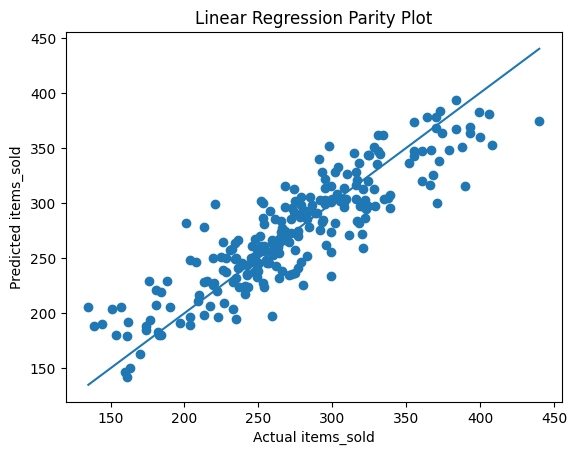

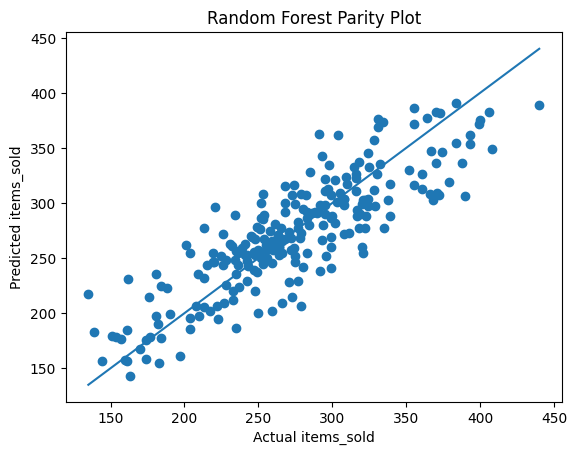

In [22]:
import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred)

    # Diagonal line
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()])

    plt.xlabel("Actual items_sold")
    plt.ylabel("Predicted items_sold")
    plt.title(title)
    plt.show()

# Plot for both models
parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

In [23]:
import pandas as pd

# Get feature names after OneHotEncoding
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_features = ohe.get_feature_names_out(categorical_cols)

# Combine with numerical features
all_features = list(encoded_features) + numerical_cols

# Get importances
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Top 5 features
print("Top 5 Most Influential Features:")
print(feature_importance_df.head())

Top 5 Most Influential Features:
                Feature  Importance
13          is_festival    0.173473
10     store_size_small    0.167683
7   location_type_urban    0.108378
17          day_of_week    0.086316
12           is_weekend    0.061208
